In [68]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import subprocess
import os

matplotlib.rcParams.update({"axes.grid": True, "font.size": 14})
# matplotlib.rcParams.keys()

Compile cpp

In [69]:
compile = subprocess.run(
    ["./compile_project"],
    capture_output=True,
    text=True
)

print(compile.stdout)
print(compile.stderr)

-- Doxygen found!
-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /home/davide/GitHub/computational_physics_2_2026/variational-monte-carlo-fys4411-DC2026/build
[  4%] Building CXX object CMakeFiles/vmc.dir/Hamiltonians/hamiltonian.cpp.o
[  8%] Building CXX object CMakeFiles/vmc.dir/Hamiltonians/harmonicoscillator.cpp.o
[ 12%] Building CXX object CMakeFiles/vmc.dir/Hamiltonians/repulsiveho.cpp.o
[ 16%] Building CXX object CMakeFiles/vmc.dir/Samplers/densitysampler.cpp.o
[ 20%] Building CXX object CMakeFiles/vmc.dir/Samplers/energysampler.cpp.o
[ 25%] Building CXX object CMakeFiles/vmc.dir/Samplers/sampler.cpp.o
[ 29%] Building CXX object CMakeFiles/vmc.dir/Solvers/metropolis.cpp.o
[ 33%] Building CXX object CMakeFiles/vmc.dir/Solvers/metropolishastings.cpp.o
[ 37%] Building CXX object CMakeFiles/vmc.dir/Solvers/montecarlo.cpp.o
[ 41%] Building CXX object CMakeFiles/vmc.dir/VMCOptimizer.cpp.o
[ 45%] Building CXX object CMakeFiles/vmc.dir/WaveFunc

In [70]:
# result = subprocess.run(
#     ["./vmc", "true"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout)
# print(result.stderr)

2D plot

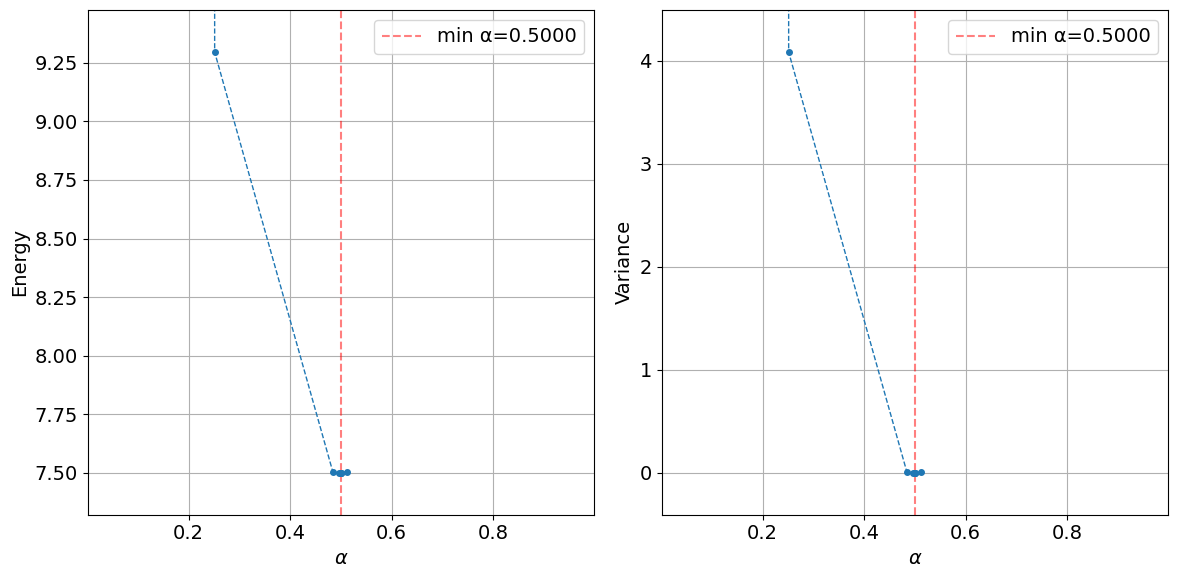

In [99]:
%matplotlib inline

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

# Skip first few iterations
burnin = 1
parameters = parameters[:, burnin:]
energy = energy[burnin:]
variance = variance[burnin:]
error = error[burnin:]

# Sort by alpha
sort_idx = np.argsort(parameters[0, :])
parameters = parameters[:, sort_idx]
energy = energy[sort_idx]
variance = variance[sort_idx]
error = error[sort_idx]

# Find minimum and compute symmetric window around it
min_idx = np.argmin(energy)
min_alpha = parameters[0, min_idx]
max_dist = np.max(np.abs(parameters[0, :] - min_alpha))

# Mask for points within the x window, excluding boundary point
mask = np.abs(parameters[0, :] - min_alpha) < 0.99 * max_dist

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0, 0])
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.errorbar(parameters[0, :], energy, error, ls='--', linewidth=1, marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
e_min, e_max = np.min(energy[mask]), np.max(energy[mask])
e_range = e_max - e_min
ax.set_ylim(e_min - 0.1 * e_range, e_max + 0.1 * e_range)
# ax.set_xlim(0.45)
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.errorbar(parameters[0, :], variance, ls='--', linewidth=1, marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
v_min, v_max = np.min(variance[mask]), np.max(variance[mask])
v_range = v_max - v_min
ax.set_ylim(v_min - 0.1 * v_range, v_max + 0.1 * v_range)
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig("iofiles/optimization2D.png", dpi=300)

3D plot

In [72]:
%matplotlib auto

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

if parameters.shape[0] == 2:
    # Skip burnin
    burnin = 8
    parameters = parameters[:, burnin:]
    energy = energy[burnin:]
    variance = variance[burnin:]
    error = error[burnin:]

    alpha = parameters[0, :]
    beta = parameters[1, :]

    fig = plt.figure(figsize=(14, 6))

    ax = fig.add_subplot(121, projection='3d')
    sc = ax.scatter(alpha, beta, energy, c=energy, cmap='viridis', s=50)
    # mark minimum
    min_idx = np.argmin(energy)
    ax.scatter(alpha[min_idx], beta[min_idx], energy[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("Energy")
    ax.legend()
    plt.colorbar(sc, ax=ax, shrink=0.5)

    ax = fig.add_subplot(122, projection='3d')
    sc = ax.scatter(alpha, beta, variance, c=variance, cmap='viridis', s=50)
    ax.scatter(alpha[min_idx], beta[min_idx], variance[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("Variance")
    ax.legend()
    plt.colorbar(sc, ax=ax, shrink=0.5)

    plt.tight_layout()
    plt.show()

Using matplotlib backend: TkAgg


Run only onedensity

In [73]:
# result = subprocess.run(
#     ["./vmc 3", "true"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout)
# print(result.stderr)

One-body density

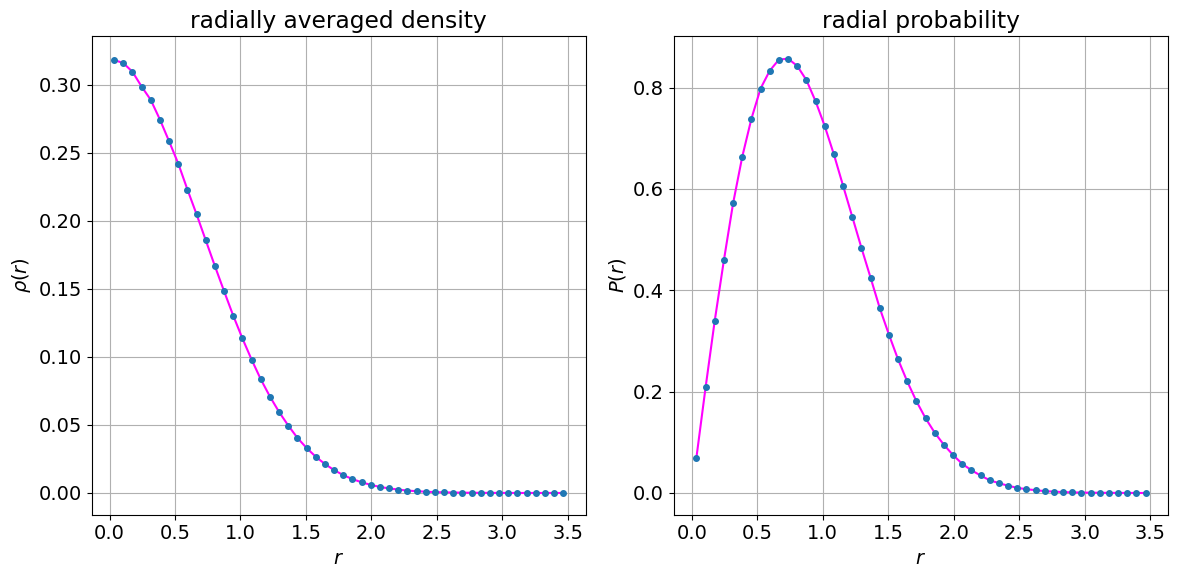

In [74]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

dim = 3
r, rho, drho, p, dp = np.loadtxt("iofiles/onebodydensity.dat", delimiter=',', unpack=True)
# r, rho, drho = np.loadtxt("iofiles/onebodydensity.dat", delimiter=',', unpack=True)
# rad_rho = rho * volume_hshpere(r, dim)
# drad_rho = drho * volume_hshpere(r, dim)

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0, 0])
ax.errorbar(r, y=rho, yerr=drho, color='magenta', ecolor='black',
            marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
ax.set_title(r"radially averaged density")
ax.set_ylabel(r"$\rho(r)$")
ax.set_xlabel(r"$r$")

ax = fig.add_subplot(gs[0, 1])
ax.errorbar(r, y=p, yerr=dp, color='magenta', ecolor='black',
            marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
# ax.errorbar(r, y=rad_rho, yerr=drad_rho, color='red', ecolor='black',
#             marker='x', markersize=8, linestyle='--', mfc="tab:green", mec="tab:green", alpha=0.4)
ax.set_title(r"radial probability")
ax.set_ylabel(r"$P(r)$")
ax.set_xlabel(r"$r$")
plt.tight_layout()
fig.savefig("./iofiles/density.png", dpi=300)

Elliptic comparison

png
onebodydensity_10N_.dat
onebodydensity_10N.dat
onebodydensity_20N.dat


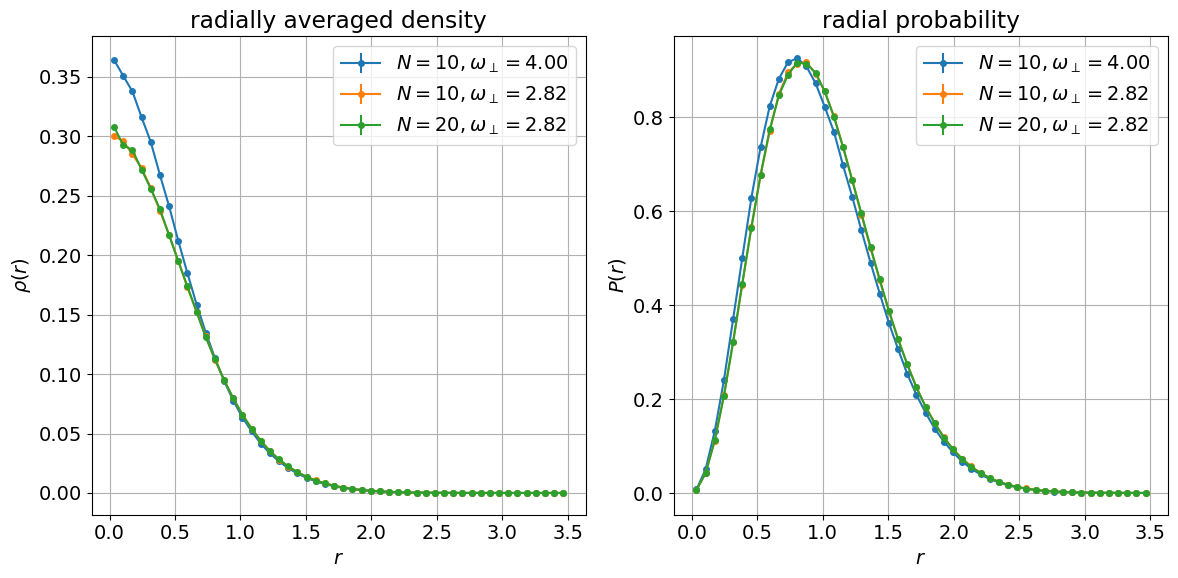

In [75]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

dim = 3
i = 0
r = [0,0,0]
rho = [0,0,0]
drho = [0,0,0]
p = [0,0,0]
dp = [0,0,0]
dirname = "images_backup/comparisonElliptic"
for file in os.listdir(os.fsencode(dirname)):
    filename = os.fsdecode(file)
    if filename[len(filename)-4:] != ".dat":
        print(filename[len(filename)-3:])
        continue
    print(filename)
    r[i], rho[i], drho[i], p[i], dp[i] = np.loadtxt(dirname + '/' + filename, delimiter=',', unpack=True)
    i += 1
r = np.array(r)
rho = np.array(rho)
drho = np.array(drho)
p = np.array(p)
dp = np.array(dp)
rho[2] /= 2
drho[2] /= 2
p[2] /= 2
dp[2] /= 2
rho /= 10
drho /= 10
p /= 10
dp /= 10
lab = [r"$N = 10, \omega_\perp = 4.00$", r"$N = 10, \omega_\perp = 2.82$", r"$N = 20, \omega_\perp = 2.82$"]

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0, 0])
for i in range(3):
    ax.errorbar(r[i], y=rho[i], yerr=drho[i], marker='.', markersize=8, linestyle='-', label=lab[i])        
ax.set_title(r"radially averaged density")
ax.set_ylabel(r"$\rho(r)$")
ax.set_xlabel(r"$r$")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
for i in range(3):
    ax.errorbar(r[i], y=p[i], yerr=dp[i], marker='.', markersize=8, linestyle='-', label=lab[i])
ax.set_title(r"radial probability")
ax.set_ylabel(r"$P(r)$")
ax.set_xlabel(r"$r$")
ax.legend()
plt.tight_layout()
fig.savefig("./images_backup/comparisonElliptic/comparison.png", dpi=300)

onebodydensity_50N.dat
onebodydensity_10N.dat
onebodydensity_100N.dat
onebodydensity_20N.dat
[1 3 0 2]


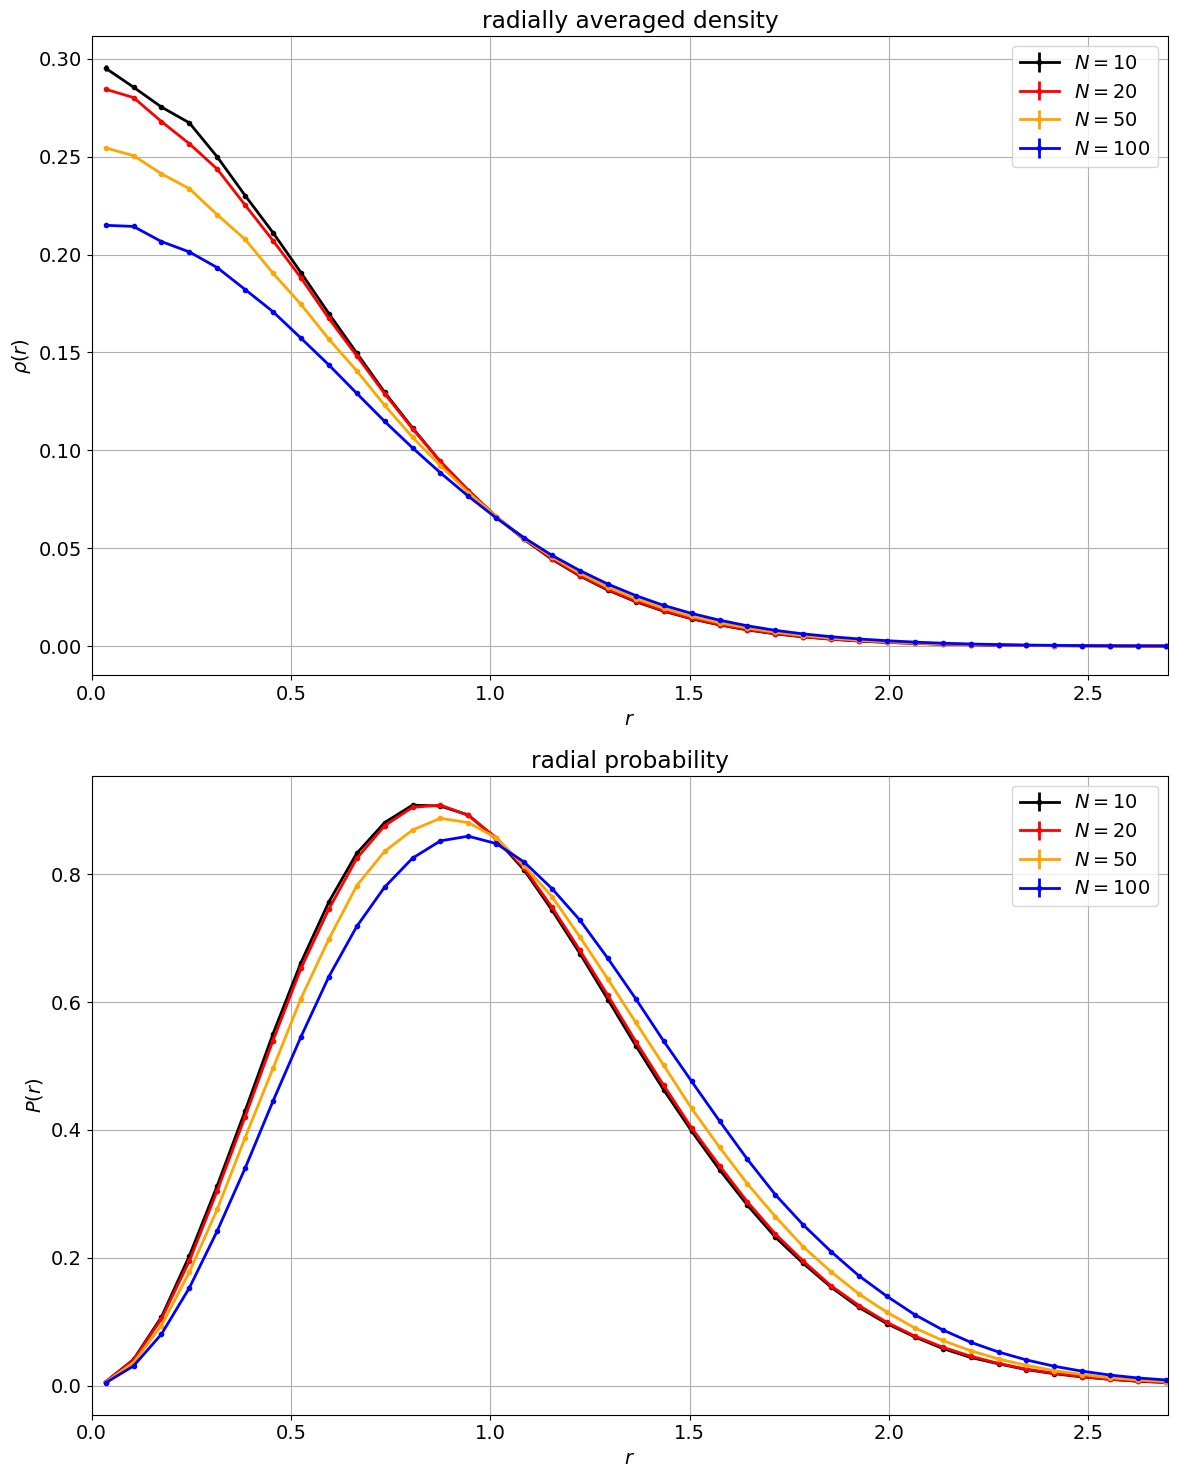

In [76]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

dim = 3
i = 0
r = [0]
rho = [0]
drho = [0]
p = [0]
dp = [0]
N = [0]
N[0] = 1
dirname = "images_backup/comparisonInteracting"
for file in os.listdir(os.fsencode(dirname)):
    filename = os.fsdecode(file)
    if filename[len(filename)-5:] != "N.dat":
        # print(filename[len(filename)-3:])
        continue
    if i > len(r) - 1:
        N.append(0)
        r.append(0)
        rho.append(0)
        drho.append(0)
        p.append(0)
        dp.append(0)
    print(filename)
    _idx = filename.find("_")
    Nidx = filename.find("N")
    N[i] = int(filename[_idx+1:Nidx])
    r[i], rho[i], drho[i], p[i], dp[i] = np.loadtxt(dirname + '/' + filename, delimiter=',', unpack=True)
    rho[i] /= N[i]
    drho[i] /= N[i]
    p[i] /= N[i]
    dp[i] /= N[i]
    i += 1
dim = i
N = np.array(N)
r = np.array(r)
rho = np.array(rho)
drho = np.array(drho)
p = np.array(p)
dp = np.array(dp)

# Sort by N
sort_idx = np.argsort(N)
print(sort_idx)
N = N[sort_idx]
r = r[sort_idx, :]
rho = rho[sort_idx, :]
drho = drho[sort_idx, :]
p = p[sort_idx, :]
dp = dp[sort_idx, :]

lab = [r"$N = $"f"{N[k]}" for k in range(dim)]
c = ["black", "red", "orange", "blue"]

fig = plt.figure(figsize=(12, 15))
gs = fig.add_gridspec(2, 1)

ax = fig.add_subplot(gs[0, 0])
# for i in range(dim-1, -1, -1):
for i in range(dim):
    ax.errorbar(r[i], y=rho[i], yerr=drho[i], marker='.', color=c[i], markersize=6, linestyle='-', linewidth=2, label=lab[i])        
ax.set_title(r"radially averaged density")
ax.set_ylabel(r"$\rho(r)$")
ax.set_xlabel(r"$r$")
ax.set_xlim(0, 2.7)
ax.legend()

ax = fig.add_subplot(gs[1, 0])
# for i in range(dim-1, -1, -1):
for i in range(dim):
    ax.errorbar(r[i], y=p[i], yerr=dp[i], marker='.', color=c[i], markersize=6, linestyle='-', linewidth=2, label=lab[i])
ax.set_title(r"radial probability")
ax.set_ylabel(r"$P(r)$")
ax.set_xlabel(r"$r$")
ax.set_xlim(0, 2.7)
ax.legend()
plt.tight_layout()
fig.savefig("./images_backup/comparisonInteracting/comparisonInteracting.png", dpi=300)

onebodydensity_50N.dat
onebodydensity_10N.dat
onebodydensity_100Nb.dat
onebodydensity_10Nb.dat
onebodydensity_100N.dat
[1, 3, 0, 4, 2]


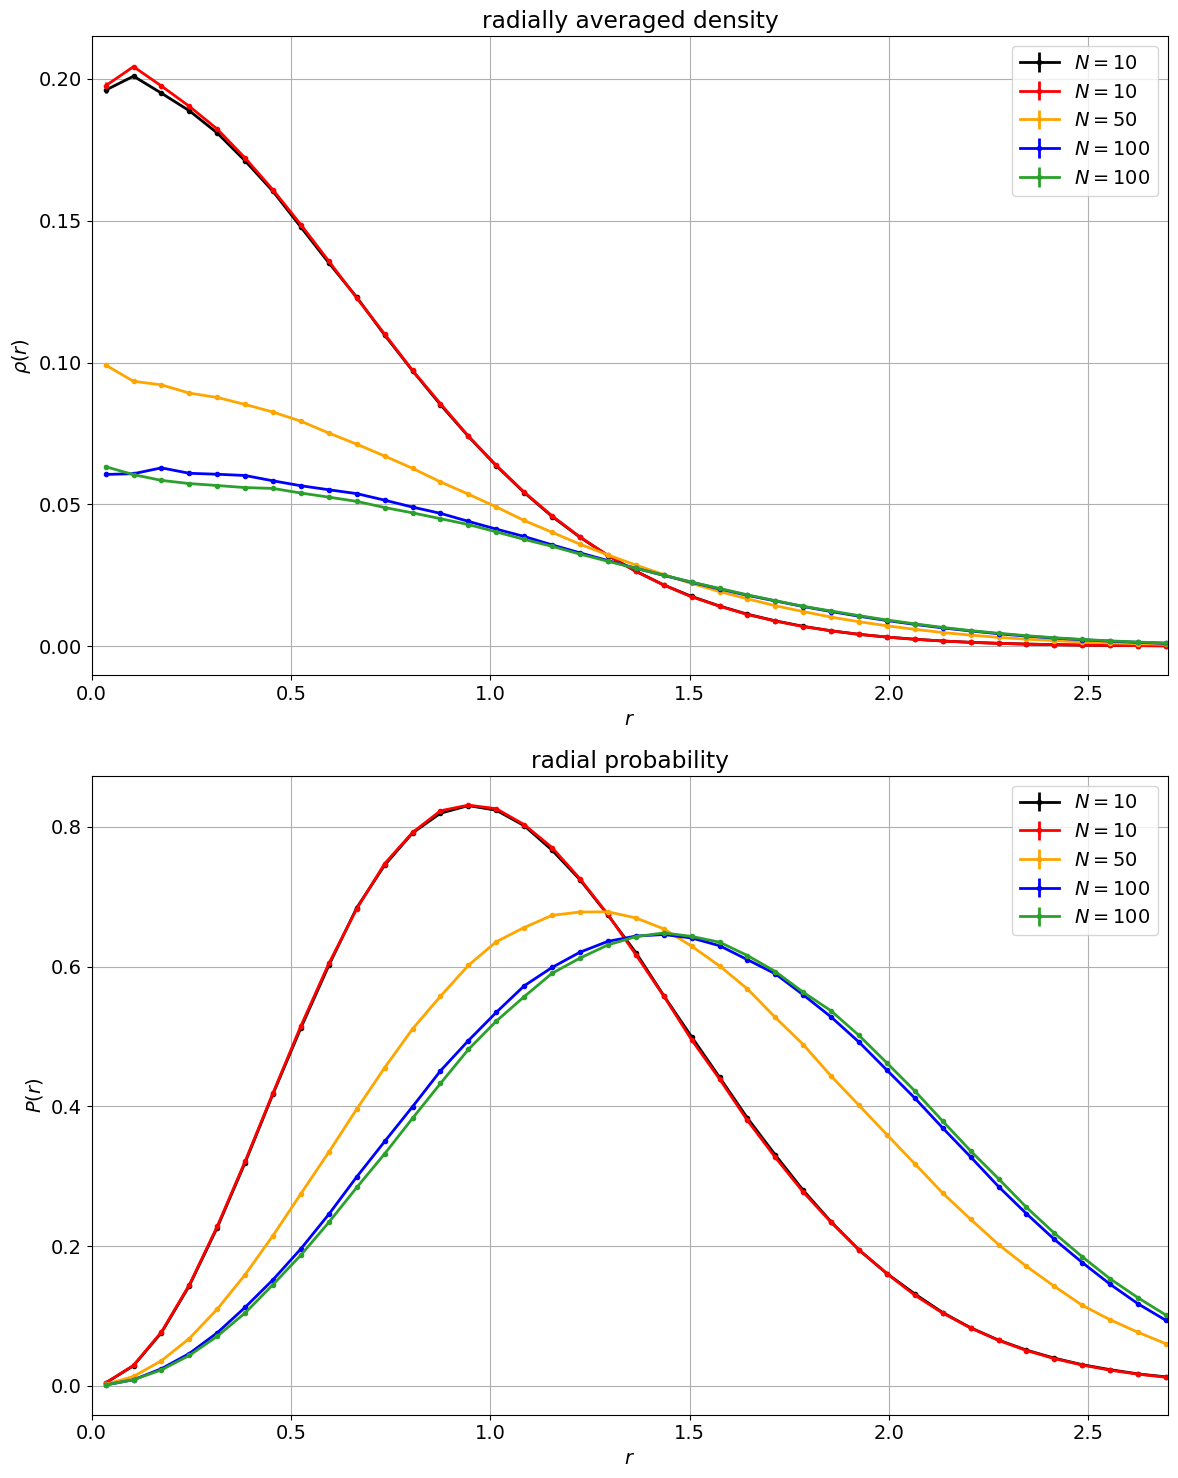

In [121]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

dim = 3
i = 0
r = [0]
rho = [0]
drho = [0]
p = [0]
dp = [0]
N = [0]
# N[0] = 1
dirname = "images_backup/comparisonInteracting_larger_a"
for file in os.listdir(os.fsencode(dirname)):
    filename = os.fsdecode(file)
    if filename[len(filename)-5:] != "N.dat" and filename[len(filename)-6:] != "Nb.dat":
        # print(filename[len(filename)-5:])
        continue
    if i > len(r) - 1:
        N.append(0)
        r.append(0)
        rho.append(0)
        drho.append(0)
        p.append(0)
        dp.append(0)
    print(filename)
    _idx = filename.find("_")
    Nidx = filename.find("N")
    N[i] = int(filename[_idx+1:Nidx])
    r[i], rho[i], drho[i], p[i], dp[i] = np.loadtxt(dirname + '/' + filename, delimiter=',', unpack=True)
    rho[i] /= N[i]
    drho[i] /= N[i]
    p[i] /= N[i]
    dp[i] /= N[i]
    i += 1
dim = i
N = np.array(N)
r = np.array(r)
rho = np.array(rho)
drho = np.array(drho)
p = np.array(p)
dp = np.array(dp)

# Sort by N
sort_idx = [1, 3, 0, 4, 2]
print(sort_idx)
N = N[sort_idx]
r = r[sort_idx, :]
rho = rho[sort_idx, :]
drho = drho[sort_idx, :]
p = p[sort_idx, :]
dp = dp[sort_idx, :]

lab = [r"$N = $"f"{N[k]}" for k in range(dim)]
c = ["black", "red", "orange", "blue", "tab:green"]

fig = plt.figure(figsize=(12, 15))
gs = fig.add_gridspec(2, 1)

ax = fig.add_subplot(gs[0, 0])
# for i in range(dim-1, -1, -1):
for i in range(dim):
    ax.errorbar(r[i], y=rho[i], yerr=drho[i], marker='.', color=c[i], markersize=6, linestyle='-', linewidth=2, label=lab[i])        
ax.set_title(r"radially averaged density")
ax.set_ylabel(r"$\rho(r)$")
ax.set_xlabel(r"$r$")
ax.set_xlim(0, 2.7)
ax.legend()

ax = fig.add_subplot(gs[1, 0])
# for i in range(dim-1, -1, -1):
for i in range(dim):
    ax.errorbar(r[i], y=p[i], yerr=dp[i], marker='.', color=c[i], markersize=6, linestyle='-', linewidth=2, label=lab[i])
ax.set_title(r"radial probability")
ax.set_ylabel(r"$P(r)$")
ax.set_xlabel(r"$r$")
ax.set_xlim(0, 2.7)
ax.legend()
plt.tight_layout()
fig.savefig("./images_backup/comparisonInteracting_larger_a/comparisonInteracting_larger_a.png", dpi=300)